In [19]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

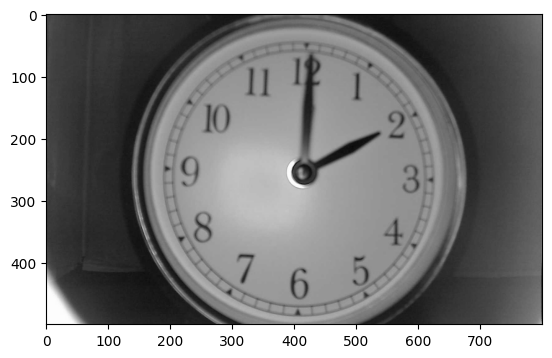

In [20]:
im = cv.cvtColor(cv.imread("../data-resampled/clock_0200.png"), cv.COLOR_BGR2RGB)
plt.imshow(im)
plt.show()

### Convertir a gris

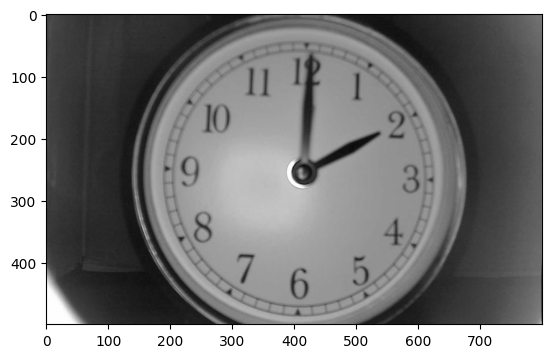

In [21]:
r,g,b = cv.split(im)

gray = 0.299*r+0.587*g+0.144*b

plt.imshow(gray, cmap="gray")

# Binarización

In [22]:
squared = gray +4

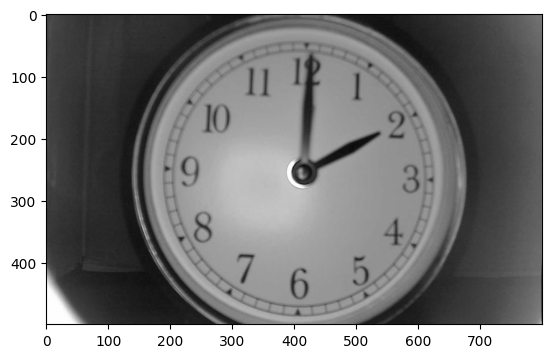

In [23]:
plt.imshow(squared, cmap="gray")
plt.show()

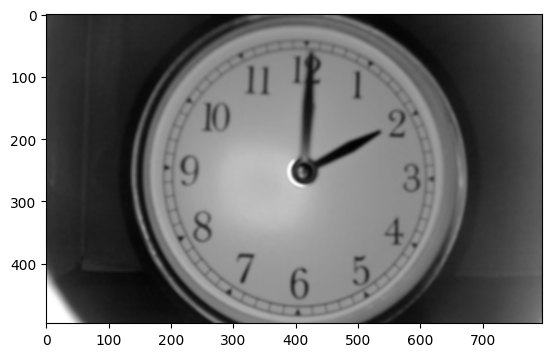

In [24]:
def conv2d(img, kernel, bias):
    m,n = kernel.shape
    if(m == n):
        x,y = img.shape
        x = (x - m) + 1
        y = (y - n) + 1
        n_img = np.zeros((x,y))
        for i in range(x):
            for j in range(y):
                n_img[i,j] = np.sum(img[i:i+m, j:j+m]*kernel) + bias
    return n_img

kernel = (1/9) * np.array([
    [1,  1,  1, 1, 1],
    [1,  1,  1, 1, 1],
    [1,  1,  1, 1, 1],
    [1,  1,  1, 1, 1],
    [1,  1,  1, 1, 1],
])


blurred_img = conv2d(gray, kernel, 2)

plt.imshow(blurred_img, cmap="gray")
plt.show()

# Hallar circulo usando hough


circles = cv.HoughCircles(blurred_img.astype(np.uint8), cv.HOUGH_GRADIENT, 1, 20, param1=10, param2=50, minRadius=220, maxRadius=225)
circles

In [25]:
circles = cv.HoughCircles(blurred_img.astype(np.uint8), cv.HOUGH_GRADIENT, 1, 20, param1=10, param2=50, minRadius=220, maxRadius=225)
circles

array([[[404.5, 261.5, 221.1]]], dtype=float32)

In [26]:
canny_copy = blurred_img.copy()
for c in circles[0]:
    (x,y,r) = c
    x = int(x)
    y = int(y)
    r = int(r)
    cv.circle(canny_copy, (x, y), r, (255, 255, 255), 4)

    

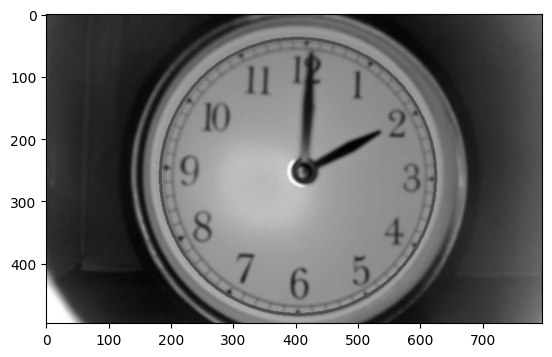

In [27]:
plt.imshow(canny_copy, cmap="gray")
plt.show()

### Segmentar manecillas

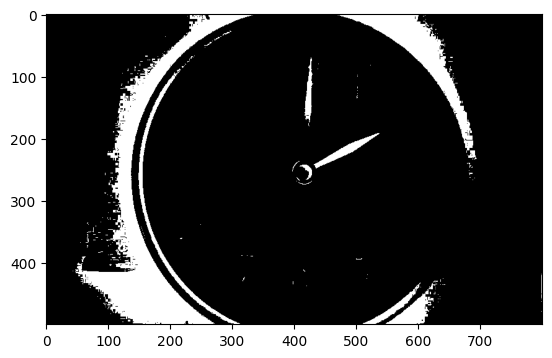

In [28]:
def umbralization(img,t, option1, option2):
    M,N = img.shape

    result = np.zeros((M,N))

    for i in range(M):
        for j in range(N):
            result[i,j] = option1 if img[i,j]  <= t  else option2


    return result



umbralized = 255 - umbralization(gray,40, 0, 255) 
plt.imshow(umbralized, cmap="gray")
plt.show()

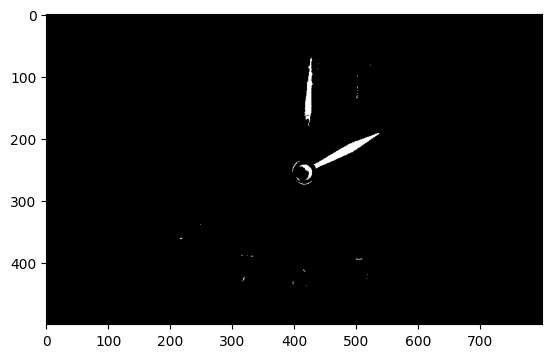

In [29]:
x_centro = int(circles[0][0][0])
y_centro = int(circles [0][0][1])
radio = int(circles[0][0][2])

(M,N) = umbralized.shape

mask = np.ones((M,N))
result = np.zeros((M,N))


for x in range(M):
    for y in range(N):
        distance = np.sqrt((y-x_centro)**2 + (x-y_centro)**2)
        mask[x,y] = True if distance <= radio else False


for x in range(M):
    for y in range(N):
        result[x,y] = umbralized[x,y] if mask[x,y] else 0


plt.imshow(result, cmap="gray")
plt.show()


In [30]:
x, y = np.where(umbralized > 0)
distance = np.sqrt((x-y_centro)**2 + (y-x_centro)**2)


In [31]:
coordenada_manecilla_grande = np.argmax(distance) ### Manecilla grande
manecilla_idx = np.where((distance > 10) & (distance < radio*0.6))[0]
coordenada_manecilla_pequeña = manecilla_idx[np.argmax(distance[manecilla_idx])]

In [32]:
distance[coordenada_manecilla_grande]

np.float64(451.164049986255)

In [33]:
distance[coordenada_manecilla_pequeña]

np.float64(132.51792331605563)

In [34]:
x_punta_g, y_punta_g = x[coordenada_manecilla_grande], y[coordenada_manecilla_grande]

In [35]:

dy = x_centro - x_punta_g
dx = y_punta_g - y_centro

theta = np.arctan2(dy, dx)

theta_reloj = (np.pi/2 - theta) % (2*np.pi)

if theta < 0:
    theta += 2*np.pi

minutos = (theta_reloj / (2*np.pi)) * 60

minutos

np.float64(16.32269725126747)

In [36]:
x_punta, y_punta = x[coordenada_manecilla_pequeña], y[coordenada_manecilla_pequeña]

dy = x_centro - x_punta
dx = y_punta - y_centro


theta = np.degrees(np.arctan2(dy, dx))

theta_reloj = (np.pi/2 - theta) % (2*np.pi)

if theta < 0:
    theta += 2*np.pi

hora = (theta_reloj / (2*np.pi)) * 12
hora

np.float64(9.837039199751251)